# Cross-Method Comparison on LiH

This benchmark extends the earlier `H2` comparison to a larger chemistry problem while keeping the notebook decision-focused rather than tutorial-style.

It compares three solver families on one shared `LiH` Hamiltonian:

- `VQE`
- `VarQITE`
- `QPE`

To keep the qubit Hamiltonian small enough for an exact reference and fast notebook iteration, the benchmark uses the same explicit active-space choice already used in the scaling notebook:

- `active_electrons=2`
- `active_orbitals=2`

Reported outputs:

- final energy
- absolute error to the exact qubit-Hamiltonian ground energy
- API-reported runtime and cache-hit status
- one short fairness note on parameter choices

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common import summarize_problem
from qite import run_qite
from qpe import run_qpe
from vqe import run_vqe

## Shared problem specification

All methods in this notebook use the exact same problem definition.

In [2]:
problem_spec = {
    "molecule": "LiH",
    "mapping": "jordan_wigner",
    "active_electrons": 2,
    "active_orbitals": 2,
}

problem_summary = summarize_problem(**problem_spec)
n_qubits = int(problem_summary["num_qubits"])
hamiltonian_terms = int(problem_summary["hamiltonian_terms"])
exact_ground = float(problem_summary["exact_ground_energy"])

spec_df = pd.DataFrame(
    {
        "setting": [
            "molecule",
            "mapping",
            "active_electrons",
            "active_orbitals",
            "num_qubits",
            "hamiltonian_terms",
            "exact_ground_energy",
        ],
        "value": [
            problem_spec["molecule"],
            problem_spec["mapping"],
            problem_spec["active_electrons"],
            problem_spec["active_orbitals"],
            n_qubits,
            hamiltonian_terms,
            exact_ground,
        ],
    }
)
spec_df

,setting,value
0,molecule,LiH
1,mapping,jordan_wigner
2,active_electrons,2
3,active_orbitals,2
4,num_qubits,4
5,hamiltonian_terms,27
6,exact_ground_energy,-7.862129


## Method configurations

The variational methods use the package defaults that are already benchmark-backed for the current release family.

For `QPE`, the baseline settings are still the small-molecule defaults exposed by the package. They are included here as a practical baseline for comparison, not as a claim that they are globally optimal for `LiH`.

In [3]:
method_configs = {
    "VQE": {
        "steps": 75,
        "stepsize": None,
        "ansatz_name": "UCCSD",
        "optimizer_name": "Adam",
        "plot": False,
        "force": False,
    },
    "VarQITE": {
        "steps": 75,
        "dtau": 0.2,
        "ansatz_name": "UCCSD",
        "plot": False,
        "show": False,
        "force": False,
    },
    "QPE": {
        "n_ancilla": 4,
        "t": 1.0,
        "trotter_steps": 2,
        "shots": 1000,
        "plot": False,
        "force": False,
    },
}

pd.DataFrame(
    [
        {"method": method, **cfg}
        for method, cfg in method_configs.items()
    ]
).fillna("")

,method,steps,stepsize,ansatz_name,optimizer_name,plot,force,dtau,show,n_ancilla,t,trotter_steps,shots
0,VQE,75.0,,UCCSD,Adam,False,False,,,,,,
1,VarQITE,75.0,,UCCSD,,False,False,0.2,False,,,,
2,QPE,,,,,False,False,,,4.0,1.0,2.0,1000.0


## Execute one run per method

In [4]:
experiments = [
    (
        "VQE",
        lambda: run_vqe(**problem_spec, **method_configs["VQE"]),
    ),
    (
        "VarQITE",
        lambda: run_qite(**problem_spec, **method_configs["VarQITE"]),
    ),
    (
        "QPE",
        lambda: run_qpe(**problem_spec, **method_configs["QPE"]),
    ),
]

def _float_or_nan(value):
    return np.nan if value is None else float(value)


rows = []
results = {}

for method, runner in experiments:
    result = runner()
    results[method] = result
    rows.append(
        {
            "method": method,
            "energy": float(result["energy"]),
            "exact_ground": exact_ground,
            "abs_error": abs(float(result["energy"]) - exact_ground),
            "runtime_s": _float_or_nan(result.get("runtime_s", np.nan)),
            "compute_runtime_s": _float_or_nan(result.get("compute_runtime_s", np.nan)),
            "cache_hit": bool(result.get("cache_hit", False)),
            "num_qubits": int(result["num_qubits"]),
        }
    )

comparison_df = pd.DataFrame(rows).sort_values(["abs_error", "runtime_s"])
display(comparison_df.round(8))

,method,energy,exact_ground,abs_error,runtime_s,compute_runtime_s,cache_hit,num_qubits
1,VarQITE,-7.862129,-7.862129,2.200000e-07,1.162672,NaN,True,4
0,VQE,-7.862128,-7.862129,6.200000e-07,1.195395,5.518632,True,4
2,QPE,-6.675884,-7.862129,1.186244e+00,1.234748,NaN,True,4


## Cache and runtime view

Two fields matter here:

- `runtime_s`: observed wall time of this API call
- `compute_runtime_s`: original compute time recorded in the run artifact

If `cache_hit=True`, `runtime_s` is expected to be much smaller than `compute_runtime_s`.

In [5]:
runtime_view = comparison_df[
    ["method", "runtime_s", "compute_runtime_s", "cache_hit"]
].sort_values("runtime_s")
runtime_view

,method,runtime_s,compute_runtime_s,cache_hit
1,VarQITE,1.162672,NaN,True
0,VQE,1.195395,5.518632,True
2,QPE,1.234748,NaN,True


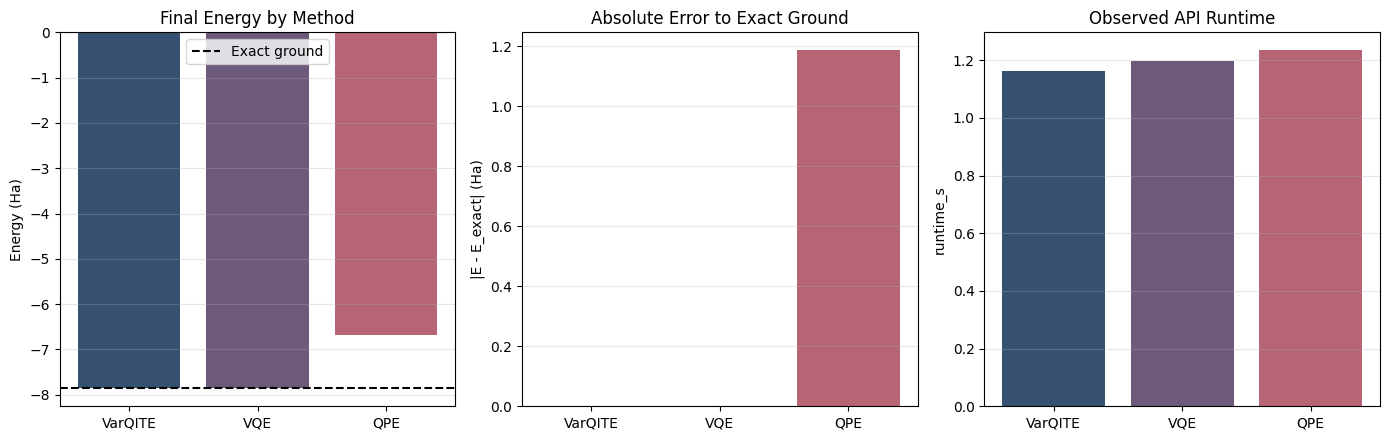

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
colors = ["#355070", "#6d597a", "#b56576"]

axes[0].bar(comparison_df["method"], comparison_df["energy"], color=colors)
axes[0].axhline(exact_ground, color="black", linestyle="--", label="Exact ground")
axes[0].set_title("Final Energy by Method")
axes[0].set_ylabel("Energy (Ha)")
axes[0].legend()

axes[1].bar(comparison_df["method"], comparison_df["abs_error"], color=colors)
axes[1].set_title("Absolute Error to Exact Ground")
axes[1].set_ylabel("|E - E_exact| (Ha)")

axes[2].bar(comparison_df["method"], comparison_df["runtime_s"], color=colors)
axes[2].set_title("Observed API Runtime")
axes[2].set_ylabel("runtime_s")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Fairness notes

- The comparison is fair on the **problem definition**: all methods use the same active-space `LiH` Hamiltonian and the same exact qubit-Hamiltonian ground reference.
- The comparison is fair on **package ergonomics**: each method is run through its public top-level entrypoint rather than a hand-tuned notebook-specific implementation.
- The comparison is **not** a claim that the `QPE` configuration is tuned for `LiH`; it is the baseline package configuration carried onto a larger system so the notebook can show what breaks first and where retuning becomes necessary.

## Suggested next step

The natural follow-on is the `LiH` reproducibility notebook:

- repeat selected runs across seeds
- separate cache-hit time from fresh-compute time
- quantify how stable the ranking remains once the smallest benchmark is no longer `H2`